# EEG Based Sleep Staging

**What is Sleep Staging?**

Sleep staging is the process of classifying sleep into distinct physiological states based on neurophysiological recordings, primarily electroencephalography (EEG). This classification is fundamental to understanding sleep architecture and diagnosing sleep disorders.

**The Five Sleep Stages:**

1. **Wake (W)**: Active consciousness with eyes open or closed, characterized by high-frequency, low-amplitude EEG activity (alpha and beta rhythms when relaxed).

2. **N1 (NREM Stage 1)**: Light sleep transition from wakefulness. EEG shows theta activity (4-8 Hz) and disappearance of alpha rhythms. Easily disrupted by external stimuli.

3. **N2 (NREM Stage 2)**: Consolidated light sleep accounting for ~50% of total sleep time. Distinguished by sleep spindles (11-16 Hz bursts in the sigma band) and K-complexes (sharp negative deflections followed by positive components).

4. **N3 (NREM Stage 3 / Slow-Wave Sleep)**: Deep restorative sleep dominated by high-amplitude delta waves (<4 Hz). Critical for physical restoration, immune function, and memory consolidation. Difficult to awaken from.

5. **REM (Rapid Eye Movement)**: Paradoxical sleep with high-frequency, low-amplitude EEG resembling wakefulness, but with muscle atonia and rapid eye movements. Primary stage for vivid dreaming and emotional memory processing.

The goal of sleep staging is to classify sleep stages (Wake, N1, N2, N3, REM) from EEG data. The sampling unit is an **epoch** (typically 30 seconds), and for each epoch we have a feature vector of powers at discrete frequencies. The challenge lies in capturing subtle spectral signatures that distinguish stages while generalizing across subjects with different age, sex, and neurophysiology.

## Your work:

You have access to a dataset of 20 subjects. Each subject has recordings from 4 different PSG channels Fpz-Cz, Pz-Oz, EOG and EMG ( in this order in the array ).

Use subjects from 0 to 14 as training subjects and keep subjects 15 to 19 as testing subjects.

Your final objective is to deploy a machine learning model capable of staging sleep epochs into the 5 different sleep stages, from Wake to REM.

The project is divided in 2 parts: (1) Data Preparation and (2) Model Deployment. In part (1) you will build a workflow to clean the signal from channels artifacts, filtering and feature extraction. In part (2) you will use the training data to deploy a Machine Learning model in sleep staging and test its performance on an unseen slice of subjects ( testing data ).

In [ ]:
# Imports
%matplotlib inline
import numpy as np
import torch
from tqdm import tqdm
from matplotlib import pyplot as plt
import os

from scipy.signal import welch
from typing import List, Tuple

from sklearn.decomposition import FastICA
from scipy.signal import butter, sosfiltfilt

import warnings


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# constants

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

STAGES = ["Wake", "N1", "N2", "N3", "REM"]
STAGE_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

CHANNELS = ["Fpz-Cz", "Pz-Oz", "EOG", "EMG"]
SUBJECTS = np.arange(20)
BANDS = {
    "delta": [0.5, 4.5],
    "theta": [4.5, 8.5],
    "alpha": [8.5, 11.5],
    "sigma": [11.5, 15.5],
    "beta": [15.5, 30],
}

fs = 100

In [ ]:
# provided utiity functions
def plot_subjects_features(
    n_subjects: int,
    X: List[np.array], y: List[np.array],
    ncol: int = 2,
    nrows: int = 1,
    figsize: Tuple[int, int] = (15, 6),
) -> None:
    """
    Plot mean PSD features per sleep stage for multiple subjects.

    Parameters
    ----------
    n_subjects : int
        Number of subjects to plot (must be <= ncol * nrows).
    X : List[Tuple[np.ndarray, np.ndarray]]
        List where each element corresponds to one subject and is a tuple:
        (features, freqs)
        features: shape (n_epochs, n_freq_bins) power spectral densities (e.g. µV²/Hz).
        freqs: shape (n_freq_bins,) frequency axis in Hz.
    y : List[np.ndarray]
        List of arrays of integer stage labels per epoch for each subject.
        Each array shape: (n_epochs,). Labels must map 0..len(STAGES)-1.
    ncol : int, default=2
        Number of subplot columns.
    nrows : int, default=1
        Number of subplot rows.
    figsize : Tuple[int, int], default=(15, 6)
        Matplotlib figure size.

    Returns
    -------
    None
        Displays the matplotlib figure with one subplot per subject.

    Notes
    -----
    - Y-axis label uses µV²/Hz (dB); ensure your input is already in desired scale.

    Example
    -------
    # Prepare data for 2 subjects
    subj_features_0, freqs_0 = features_subject_0, freqs
    subj_features_1, freqs_1 = features_subject_1, freqs
    X_plot = [(subj_features_0, freqs_0), (subj_features_1, freqs_1)]
    y_plot = [stages_subject_0, stages_subject_1]

    plot_subjects_features(
        n_subjects=2,
        X=X_plot,
        y=y_plot,
        ncol=2,
        nrows=1,
        figsize=(10, 4),
    )
    """

    fig, axs = plt.subplots(
        ncols=ncol, nrows=nrows, sharey="row", sharex=True, figsize=figsize
    )
    axs = axs.flatten()

    for i in tqdm(range(n_subjects), desc="Reading data"):
        features, freqs = X[i]
        stages = y[i]

        ax = axs[i]
        ax.set_title(f"Subject {i + 1}")

        for stage_id, stage in enumerate(STAGES):
            psd_stage = features[stages == stage_id]

            mean_psd = np.mean(psd_stage, axis=0)

            x_freqs = freqs
            mean_psd = mean_psd

            ax.plot(
                x_freqs.astype(float),
                mean_psd,
                label=stage,
                color=STAGE_COLORS[stage_id],
                linewidth=0.5,
            )

        # lines dividing each band
        # suppress warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for band, (fmin, fmax) in BANDS.items():
                ax.axvline(fmin, color="k", linestyle="-.", linewidth=0.5)

                if band == "beta":
                    ax.axvline(fmax, color="k", linestyle="-.", linewidth=0.5)

                ax.text(
                    (fmin + fmax) / 2,
                    ax.get_ylim()[1] - 5,
                    f"$\{band}$",
                    horizontalalignment="center",
                    verticalalignment="top",
                    fontsize=8,
                    color="k",
                    alpha=0.7,
                )

        ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

        if i >= (nrows - 1) * ncol:
            ax.set_xlabel("Frequency (Hz)")

        if i % ncol == 0:
            ax.set(ylabel="µV²/Hz (dB)")

        ax.set_xlim(0, 30)

    # Add legend to the last subplot
    handles = [plt.Line2D([0], [0], color=color, lw=2) for color in STAGE_COLORS]
    labels = STAGES
    axs[-1].legend(handles, labels, loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()

    return

<>:99: SyntaxWarning: invalid escape sequence '\{'
<>:99: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipython-input-3955643298.py:99: SyntaxWarning: invalid escape sequence '\{'
  f"$\{band}$",


## 1. Data Preparation

### Task 0 — Data Loading

Goal: load and inspect the provided PSG recordings and prepare them for the preprocessing pipeline.

Code already provided here, just run the cell !


In [ ]:
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/Biomedical Data Processing/new /BDP project/AssignmentPartII"))

['2025_project_part2.ipynb', 'data.zip', '2025-overviewsheet-part2.docx', '.ipynb_checkpoints', 'data']


In [ ]:
X , y = [], []

BASE = "/content/drive/MyDrive/Colab Notebooks/Biomedical Data Processing/new /BDP project/AssignmentPartII"

for i in tqdm(SUBJECTS, desc = "Fetching data"):
    # load the data
    signal = torch.load(f"{BASE}/data/signals/subject_{i}.pt".format(i) )
    stages = torch.load(f"{BASE}/data/stages/subject_{i}.pt".format(i) )
    # signal = torch.load( "data/signals/subject_{}.pt".format(i) )
    # stages = torch.load( "data/stages/subject_{}.pt".format(i) )

    X.append( signal.float().numpy() )
    y.append( stages.long().numpy() - 1)

print( "Data Loaded." )
print( "Subject 0 shape: ", X[0].shape, " Subject 0 stages shape: ", y[0].shape )

print( "Shape 1 : Number of windows \nShape 2 : Number of channels (Fpz-Cz Pz-Oz EOG EMG)\nShape 3 : Number of time samples per window ( 30s x 100 fs ), units: V" )

Fetching data: 100%|██████████| 20/20 [00:48<00:00,  2.42s/it]

Data Loaded.
Subject 0 shape:  (841, 4, 3000)  Subject 0 stages shape:  (841,)
Shape 1 : Number of windows 
Shape 2 : Number of channels (Fpz-Cz Pz-Oz EOG EMG)
Shape 3 : Number of time samples per window ( 30s x 100 fs ), units: V


### Task 1 — Visualize a single epoch

Goal: provide a compact plotting routine to inspect raw epochs for visualization of the different channels signals.

Deliverables:
- Implement code that, given `subject` and `epoch` indices, plots a figure with 4 stacked subplots (one per channel in order: Fpz-Cz, Pz-Oz, EOG, EMG).
- The figure title must include the subject id, epoch index, and the annotated stage name (e.g. `Stage: Wake`).
- Add y-axis labels (µV) for clarity and a shared x-axis labelled in seconds.
- Discuss visible patterns characterizing each sleep stage in markdown specifying the epoch id and subject id they refer to.

In [ ]:
# set subject and epoch
epoch = 10
subject = 3

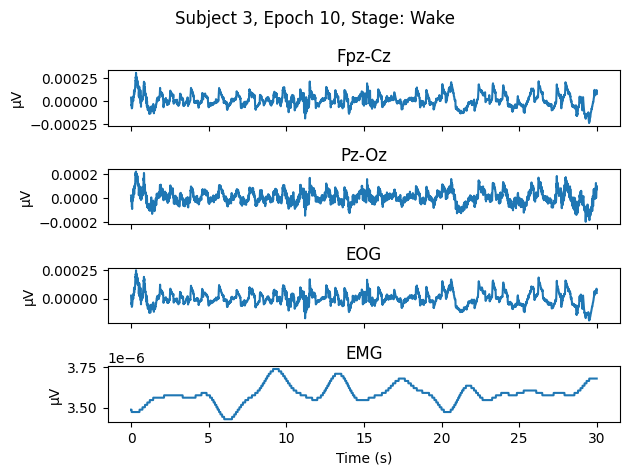

In [ ]:
# write the plotting routine here

def plot_epoch(subject, epoch, X, y, fs=100):
  signal = X[subject][epoch]
  stage = STAGES[y[subject][epoch]]

  t = np.arange(signal.shape[1]) / fs
  fig, axs = plt.subplots(4, 1, sharex=True)

  fig.suptitle(f"Subject {subject}, Epoch {epoch}, Stage: {stage}")

  for i, ax in enumerate(axs):
      ax.plot(t, signal[i])
      ax.set_ylabel("µV")
      ax.set_title(CHANNELS[i])

  plt.xlabel("Time (s)")
  plt.tight_layout()
  plt.show()

plot_epoch(subject, epoch, X, y)

write the discussion in markdown here

In both EEG channels (Fpz-Cz and Pz-Oz) we can see low amplitude signals but fast and irregular. There are not any spindles or k-complexed. This pattern is most typical during wakefulness.

The EOG signal is also low amplitude and high frequency, typical of normal eye movement.

The EMG signal has high amplitude which demonstrates high activity. Hence supporting the conclusion from the aforementioned discussion. This signal implies wakefulness.

In [ ]:
print(f"Sleep stage of subject {subject}, window {epoch}:", STAGES[y[subject][epoch]])
# print(np.unique(y[2]))

Sleep stage of subject 3, window 10: Wake


### Task 2 — Removal of EOG / EMG artefacts from EEG

Goal: use ICA to separate reference artefact channels (EOG, EMG) from EEG and produce a reproducible artefact-removal step for the pipeline.

Deliverables:
- Fit a reproducible FastICA model on the training subjects (subjects 0–14). Document which data were concatenated and the final training shape used for ICA.
- Explain and implement the correct reshaping required by scikit-learn ICA.

In [ ]:
# fit the ICA model
# take care of ICA randomness
# Note: ICA fit function takes as input n_samples x n_channels data.

# How should you reshape the data properly ?
# A: In order to reshape the data properly we need to first switch the channels with the samples and then
# we can multiply the epochs with the samples because we need all samples to feed the ICA
# since we have 3000 dimensional samples, meaning 30s * 100Hz, we multiply them with the epochs
# and we have 47280000 total samples across subjects

X_train = []

for subject in range(15): #0-14
  data = X[subject]
  data = np.swapaxes(data, 1, 2) #swap channels with samples
  data = data.reshape(-1, 4) # multiply epochs with samples
  X_train.append(data)

X_train = np.vstack(X_train)

In [ ]:
print(X_train.shape) #total samples across subjects, 4

(47280000, 4)


In [ ]:
ica = FastICA(
    n_components=4,
    random_state=RANDOM_SEED,
    whiten='unit-variance',
    max_iter=1000,
)

In [ ]:
ica.fit(X_train)

FastICA(max_iter=1000, n_components=4, random_state=42)

### Task 2.1 — Visual inspection of ICA components

Goal: inspect and nominate independent components that capture ocular and muscular artefacts.

Deliverables:
- For a chosen subject and epoch, plot all its ICA transformed components alongside the original EOG and EMG channels so associations are visually evident.

Note:
- Take care of signal reshaping before and after ICA transformation

Additional Questions:
- Identify which components are likely EOG-related and which are EMG-related. Provide a short rationale for each identification.
- Discuss the effect of including vs excluding EOG/EMG channels from ICA input.

In [ ]:
subject = 3
epoch = 10

raw = X[subject][epoch]            # shape (4, 3000)
raw_T = raw.T                      # shape (3000, 4) -> needed for ICA

S = ica.transform(raw_T)           # shape (3000, 4) -> components
S = S.T                             # shape (4, 3000) for plotting

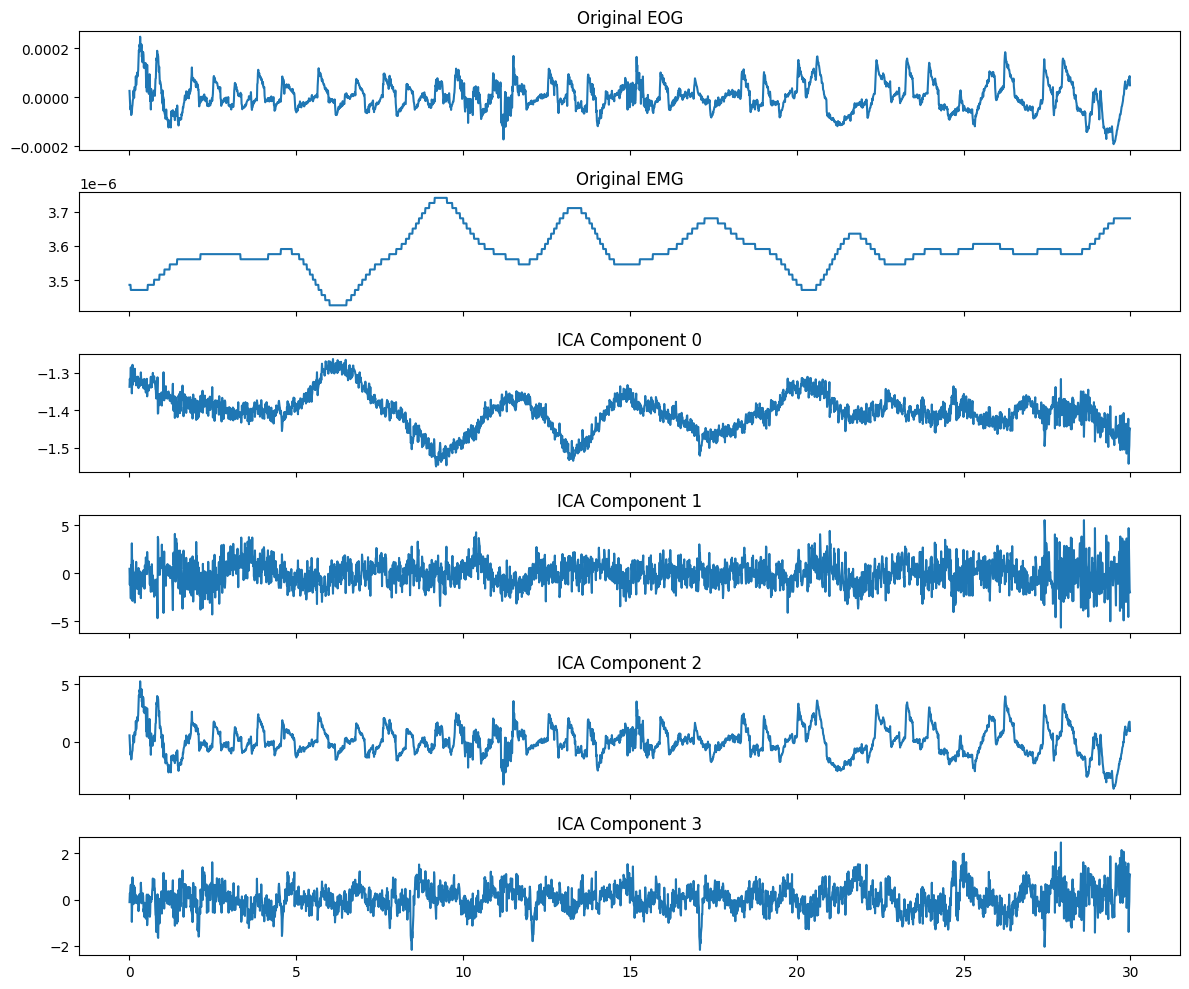

In [ ]:
fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

t = np.arange(signal.shape[1]) / fs

# original EOG & EMG
axs[0].plot(t, raw[2])
axs[0].set_title("Original EOG")
axs[1].plot(t, raw[3])
axs[1].set_title("Original EMG")

# ICA components
for k in range(4):
    axs[k+2].plot(t, S[k])
    axs[k+2].set_title(f"ICA Component {k}")

plt.tight_layout()
plt.show()


### Task 2.2 — Automatic ICA component elimination

Goal: implement a reproducible, automated procedure that nominates and removes ICA components associated with ocular (EOG) and muscular (EMG) artefacts and returns denoised EEG epochs.

Deliverables:
- Compute an association metric between each independent component and the reference artefact channels (EOG and EMG). Use Pearson correlation on concatenated component time series as metric.
- Define a deterministic selection rule (e.g., select the component with maximum absolute correlation ).
- After selecting EOG/EMG components, set their activity to zero and perform the inverse ICA transform to reconstruct denoised signals.
- Return de-mixed EEG channels (Fpz-Cz, Pz-Oz) in the original shape (n_epochs, n_channels=2, n_samples).

Additional Questions:
- Visualize the signal before and after applying ICA for sanity checking with a figure ( 2 rows: one for Fpz-Cz and one for Pz-Oz).
- On each row visualize the original signal and the de-mixed on top of each other with different colors.

In [ ]:
# automatically identify artifact components using correlation with EOG and EMG channels
from scipy.stats import pearsonr

def identify_artifact_components(X_sub, ica):
    """
    X_sub: (n_epochs, 4, n_samples)
    returns: indices of EOG and EMG components
    """
    n_epochs, n_ch, n_samples = X_sub.shape

    # reshape to (samples_total, 4)
    X2d = np.swapaxes(X_sub, 1, 2).reshape(-1, 4)

    # ICA transform
    S = ica.transform(X2d)         # (T, 4)

    # reference channels
    eog_ts = X2d[:, 2]             # original EOG mixed signal
    emg_ts = X2d[:, 3]             # original EMG mixed signal

    # pearson correlation
    corr_eog = np.array([abs(np.corrcoef(S[:, k], eog_ts)[0, 1])
                         for k in range(S.shape[1])])
    corr_emg = np.array([abs(np.corrcoef(S[:, k], emg_ts)[0, 1])
                         for k in range(S.shape[1])])

    eog_idx = int(np.argmax(corr_eog))
    emg_idx = int(np.argmax(corr_emg))

    return eog_idx, emg_idx

def denoise_subject_with_ica(X_sub, ica, eog_idx, emg_idx):
    """
    Returns cleaned EEG (Fpz-Cz, Pz-Oz) with shape (n_epochs, 2, n_samples)
    """
    n_epochs, n_ch, n_samples = X_sub.shape

    # reshape to ICA format
    X2d = np.swapaxes(X_sub, 1, 2).reshape(-1, 4)

    # forward transform
    S = ica.transform(X2d)

    # zero out artefacts
    S[:, eog_idx] = 0
    S[:, emg_idx] = 0

    # inverse transform back to mixed channel space
    X2d_clean = ica.inverse_transform(S)

    # reshape back to (n_epochs, 4, n_samples)
    X_clean = X2d_clean.reshape(n_epochs, n_samples, 4)
    X_clean = np.swapaxes(X_clean, 1, 2)

    # keep EEG only
    return X_clean[:, :2, :]

In [ ]:
# Apply the ICA transformation to both train and test data subject-wise
X_clean_all = []

for subj in SUBJECTS:
    print(f"Processing subject {subj}...")

    # 1. Identify EOG + EMG components
    eog_idx, emg_idx = identify_artifact_components(X[subj], ica)

    # 2. Clean the subject using identified components
    X_clean_sub = denoise_subject_with_ica(X[subj], ica, eog_idx, emg_idx)

    X_clean_all.append(X_clean_sub)

print("All subjects denoised.")

Processing subject 0...
Processing subject 1...
Processing subject 2...
Processing subject 3...
Processing subject 4...
Processing subject 5...
Processing subject 6...
Processing subject 7...
Processing subject 8...
Processing subject 9...
Processing subject 10...
Processing subject 11...
Processing subject 12...
Processing subject 13...
Processing subject 14...
Processing subject 15...
Processing subject 16...
Processing subject 17...
Processing subject 18...
Processing subject 19...
All subjects denoised.


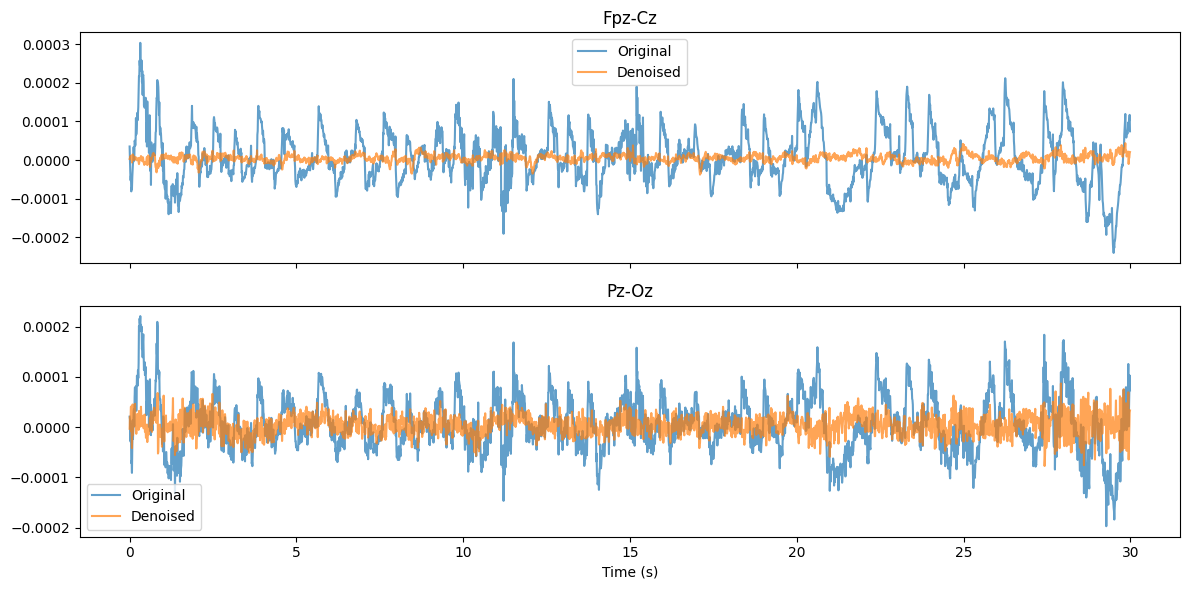

In [ ]:
# plot the denoised EEG signal before and after removing the identified components

subject = 3
epoch = 10

def plot_before_after(subject, epoch, X_raw, X_clean, fs=100):
    t = np.arange(X_raw[subject].shape[-1]) / fs

    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Fpz-Cz
    axs[0].plot(t, X_raw[subject][epoch, 0], label="Original", alpha=0.7)
    axs[0].plot(t, X_clean[subject][epoch, 0], label="Denoised", alpha=0.7)
    axs[0].set_title("Fpz-Cz")
    axs[0].legend()

    # Pz-Oz
    axs[1].plot(t, X_raw[subject][epoch, 1], label="Original", alpha=0.7)
    axs[1].plot(t, X_clean[subject][epoch, 1], label="Denoised", alpha=0.7)
    axs[1].set_title("Pz-Oz")
    axs[1].set_xlabel("Time (s)")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

plot_before_after(subject, epoch, X, X_clean_all)

### Task 3 — Signal Filtering

Goal: design and apply a filter that preserves EEG spectral content relevant for sleep staging while removing slow drifts and high-frequency noise.

Deliverables:
- Choose and justify filter parameters (type, passband, order). Suggestion: use scipy.signal.sosfiltfilt for numerical stability.
- Implement a reusable filter function and apply it to the selected EEG channel(s) for all subjects.
- Demonstrate the effect of filtering: plot an example epoch before and after filtering (time-domain) and show the PSD (Welch) before/after to confirm expected attenuation.

Additional Question:
- Should you filter before or after ICA artifacts removal  ?

In [72]:
# select a single EEG channel for sleep staging, e.g. Fpz-Cz
subject = 3
epoch = 10
channel = 0   # 0 = Fpz-Cz, 1 = Pz-Oz

raw_signal = X_clean_all[subject][epoch, channel]   # denoised by ICA


# at this point we can proceed with signal filtering to isolate the important EEG bands and remove slow-drift or high frequency noise

def bandpass_filter(x, fs=100, f_low=0.5, f_high=30, order=4):
    sos = butter(order, [f_low, f_high], btype="band", fs=fs, output="sos")
    return sosfiltfilt(sos, x)

filtered_signal = bandpass_filter(raw_signal)

I use here 4th order butterworth bandpass filter (0.5-30Hz) applied with zero-phase sosfiltfilt. This passband preserves the main EEG rhythms relevang for sleep staging, while the high-pass at 0.5 Hz removed slow drifts and the low-pass at 30 Hz suppresses high-frequency noirse and residual EMG activity.

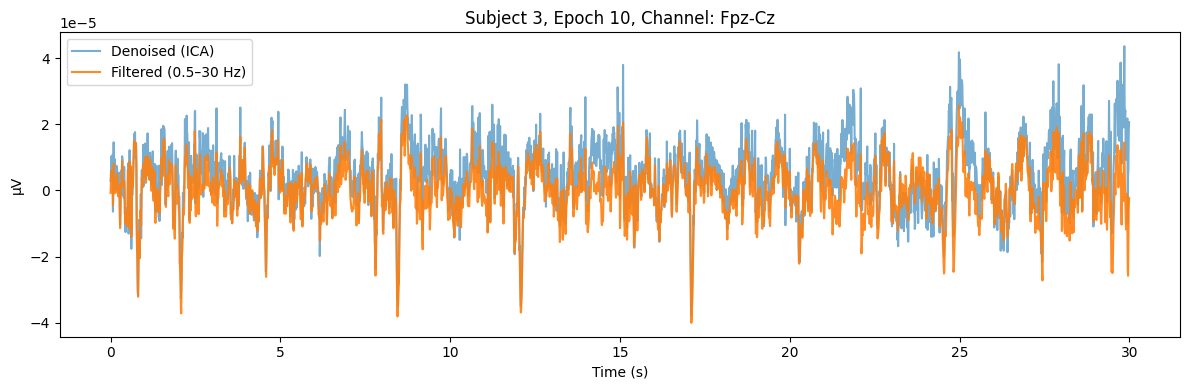

In [73]:
# plot the final denoised and filtered signal for a given subject and epoch vs original raw signal
fs = 100
t = np.arange(raw_signal.shape[-1]) / fs

plt.figure(figsize=(12,4))
plt.plot(t, raw_signal, label="Denoised (ICA)", alpha=0.6)
plt.plot(t, filtered_signal, label="Filtered (0.5–30 Hz)", alpha=0.9)
plt.xlabel("Time (s)")
plt.ylabel("µV")
plt.title(f"Subject {subject}, Epoch {epoch}, Channel: {CHANNELS[channel]}")
plt.legend()
plt.tight_layout()
plt.show()

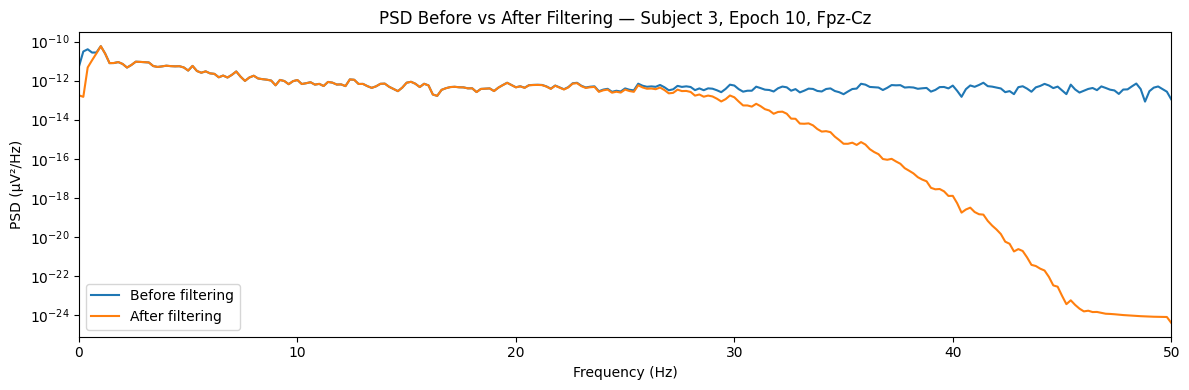

In [74]:
# PSD  (welch)
f_raw, P_raw = welch(raw_signal, fs=fs, nperseg=500)
f_filt, P_filt = welch(filtered_signal, fs=fs, nperseg=500)

plt.figure(figsize=(12,4))
plt.semilogy(f_raw, P_raw, label="Before filtering")
plt.semilogy(f_filt, P_filt, label="After filtering")
plt.xlim(0, 50)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (µV²/Hz)")
plt.title(f"PSD Before vs After Filtering — Subject {subject}, Epoch {epoch}, {CHANNELS[channel]}")
plt.legend()
plt.tight_layout()
plt.show()

We should apply ICA first and then to apply the bandpass filter after artifact removal, because ICA needs access to the full spectral content of the signals to reliably separate independent sources.

### Task 4 — Feature Extraction

Goal: extract a compact set of spectral features from each epoch suitable for supervised sleep staging.

Deliverables:
- Compute power spectral density (PSD) features for each epoch using Welch's method and convert them to a suitable scale (dB). Return features shaped (n_epochs, n_freq_bins) per patient and the corresponding frequency vector.
- Optional (Bonus Points): propose additional features that may help staging. Should also other channels ( i.e. EOG and/or EMG ) be taken into consideration ?
- Provide summary visualization with the provided psd-feature plotting function and use box-plots for any other feature.

Additional Question:
- Is high/low/bandpass filtering needed if we remove the reduced frequencies afterwards during feature extraction? Why (not) ?

In [77]:
# extract features from the cleaned EEG signals

def extract_psd_features(X_clean_sub, fs=100, nperseg=300):
    """
    X_clean_sub: (n_epochs, 2, n_samples) — cleaned & filtered EEG for one subject
    returns:
        features: list of length 2, each entry shape (n_epochs, n_freq_bins)
        freqs: frequency vector returned by welch
    """
    n_epochs, n_ch, n_samples = X_clean_sub.shape
    psd_features = []

    for ch in range(n_ch):
        feats = []
        for ep in range(n_epochs):
            freqs, Pxx = welch(X_clean_sub[ep, ch], fs=fs, nperseg=nperseg)
            Pxx_dB = 10 * np.log10(Pxx + 1e-12)
            feats.append(Pxx_dB)
        psd_features.append(np.vstack(feats))

    return psd_features, freqs


# compute PSD features for all subjects
PSD_all = []     # each entry: [features_ch0, features_ch1]
freqs_all = None

for subj in tqdm(SUBJECTS, desc="Extracting PSD features"):
    feats, f = extract_psd_features(X_clean_all[subj])
    PSD_all.append(feats)
    freqs_all = f

# extract any other feature you may consider useful for sleep staging

def extract_bandpower(signal, fs, band):
    from scipy.signal import welch
    freqs, Pxx = welch(signal, fs=fs, nperseg=300)
    fmin, fmax = band
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(Pxx[mask], freqs[mask])

BANDPOWER_all = []

for subj in tqdm(SUBJECTS, desc="Extracting bandpower features"):
    Xsub = X_clean_all[subj]
    n_epochs = Xsub.shape[0]
    bp_feats = []

    for ep in range(n_epochs):
        epoch_bp = []
        for ch in [0,1]:    # EEG channels only
            for band in BANDS.values():
                epoch_bp.append(extract_bandpower(X_clean_all[subj][ep, ch], fs, band))
        bp_feats.append(epoch_bp)
    BANDPOWER_all.append(np.array(bp_feats))


Extracting bandpower features:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipython-input-2525164223.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(Pxx[mask], freqs[mask])
Extracting bandpower features: 100%|██████████| 20/20 [05:36<00:00, 16.81s/it]


Reading data: 100%|██████████| 2/2 [00:00<00:00, 82.65it/s]


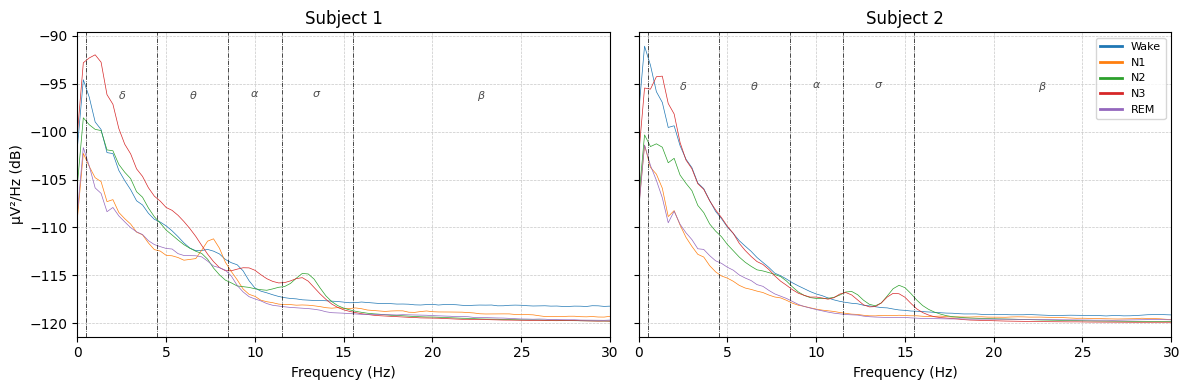

In [78]:
# now visualize the extracted features for a given subject and epoch
# you can use the plot_subjects_features to visualize the psd features
# plot_subjects_features( n_subjects = 2, X = ... , y = ... , ncol=2, nrows=1, figsize=(6, 6) )


X_plot = []
y_plot = []

for subj in range(2):            # first two subjects for example
    X_plot.append((PSD_all[subj][0], freqs_all))   # channel 0 PSD
    y_plot.append(y[subj])

plot_subjects_features(
    n_subjects=2,
    X=X_plot,
    y=y_plot,
    ncol=2,
    nrows=1,
    figsize=(12, 4)
)

## 2. Machine Learning Model deployment
In this section you need to deploy a single machine learning model ( from sklearn ), and evaluate its performances on an unknown set of subjects ( id from 15 to 20 ). This evaluation needs to be done using the sklearn classification report and the confusion matrix.

To set the type of model you want to deploy and to decide its hyperparameters you are asked to build a cross-validation ( leave-one-subject-out ) and evaluate a set of metrics. The model maximising those metrics needs to be chosen to be deployed and tested on the testing set.

The results of the cross validation should be a table (pandas.DataFrame) including all the trials of the different pipelines, models and hyperparameters you tried during this phase. Any combination not explicitly listed in the table cannot be used as a motivation for the discussion during the oral exam, so be sure to include all the trials you made.

An exhaustive cross validation should include
- Feature aggregation mechanisms for dimensionality reduction
- Different sklearn models
- Different hyperparameters of the same model

In [79]:
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
from tqdm import tqdm

# preprocessing pipeline
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

from sklearn.base import clone
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as tree
from sklearn.svm import SVC

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)

from pickle import dump, load

### Task 1 — Define scoring, classifiers and cross-validation split

Goal: define the evaluation metrics, candidate classifiers, and implement a subject-wise cross-validation split suitable for PSG data.

Deliverables:
- Select and justify a set of scoring metrics and document their rationale.
- List all the different preprocessing steps configurations ( e.g. dimensionality reduction, scaling ).
- List the classifiers and hyperparameters.
- Implement the leave-one-subject-out cross-validation (LOSO) split using a `groups` array so folds are subject-separated. Note: you must only use training data during cross-validation.

Note:
- The comparison of different preprocessing steps should include: manual dimensionality reduction vs automatic ( e.g. averaging the EEG bands vs PCA with different number of components )
- Choosing the best classifier should also include varing its parameters ( e.g. for K-NN varying the number of K ).


### Task 2 — Perform cross-validation and visualize results

Goal: build all the different pipelines as a combination of preprocessing + classifier and run the LOSO cross-validation experiments using the `cross_validate` sklearn method.
Present the results in a pandas.DataFrame to identify the best model.

Deliverables:
- Run cross-validation for each pipeline and collect mean ± std for each scoring metric across folds.
- Produce a pandas.DataFrame summarizing results per classifier (rows) and metrics (columns) with mean ± std formatting.
- Visualize the pandas table at the end

Additional Question:
- Which is the best model ? Why?

### Task 3 — Deploy the best model and test it on the held-out subjects

Goal: train the selected pipeline on the full training set and evaluate on subjects 15–19 (the held-out test set).

Deliverables:
- Retrain the chosen pipeline on the entire training set (subjects 0–14)
- Run predictions on each test subject (15–19).
- Display a normalized confusion matrix (subjects combined) and print a pandas-formatted (DataFrame) classification report.

Additional Questions:
- Are your results in-line with your expectations?
- Can you do anything based on these results to improve your model?
